In [223]:
# imports
# importamos librerias 
import numpy as np
import pandas as pd
pd.options.mode.copy_on_write = True 

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

from collections import Counter
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE

## Leemos el csv 


In [361]:
iris = pd.read_csv('./iris-data.csv')

In [362]:
iris.head(82)

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,class
0,5.100,3.5,1.4,0.2,Iris-setosa
1,4.900,3.0,1.4,0.2,Iris-setosa
2,4.700,3.2,1.3,0.2,Iris-setosa
3,4.600,3.1,1.5,0.2,Iris-setosa
4,5.000,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
77,0.067,3.0,5.0,1.7,Iris-versicolor
78,0.060,2.9,4.5,1.5,Iris-versicolor
79,0.057,2.6,3.5,1.0,Iris-versicolor
80,0.055,2.4,3.8,1.1,Iris-versicolor


## Realizamos un EDA de los datos

In [364]:
# vemos si tiene nulos y su tipo de dato 
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sepal_length_cm  150 non-null    float64
 1   sepal_width_cm   150 non-null    float64
 2   petal_length_cm  150 non-null    float64
 3   petal_width_cm   145 non-null    float64
 4   class            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [365]:
# vemos un resumen de sus  datos 
iris.describe()

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm
count,150.000000,150.000000,150.000000,145.000000
mean,5.644627,3.054667,3.758667,1.236552
std,1.312781,0.433123,1.764420,0.755058
min,0.055000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.400000
50%,5.700000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Identificamos los tipos de varibles 

In [366]:
categoricas = iris["class"]

In [367]:
# variable categorica 
iris["class"].unique()

array(['Iris-setosa', 'Iris-setossa', 'Iris-versicolor', 'versicolor',
       'Iris-virginica'], dtype=object)

In [368]:
# Contar cuántas observaciones hay en cada clase de la columna 'class'
conteo_clases = iris['class'].value_counts()

# Mostrar el resultado
print(conteo_clases)


class
Iris-virginica     50
Iris-setosa        49
Iris-versicolor    45
versicolor          5
Iris-setossa        1
Name: count, dtype: int64


In [369]:
iris["class"].nunique()

5

In [370]:
numericas = iris[["sepal_length_cm", "sepal_width_cm", "petal_length_cm", "petal_width_cm"]]


In [371]:
numericas 

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,2.3
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


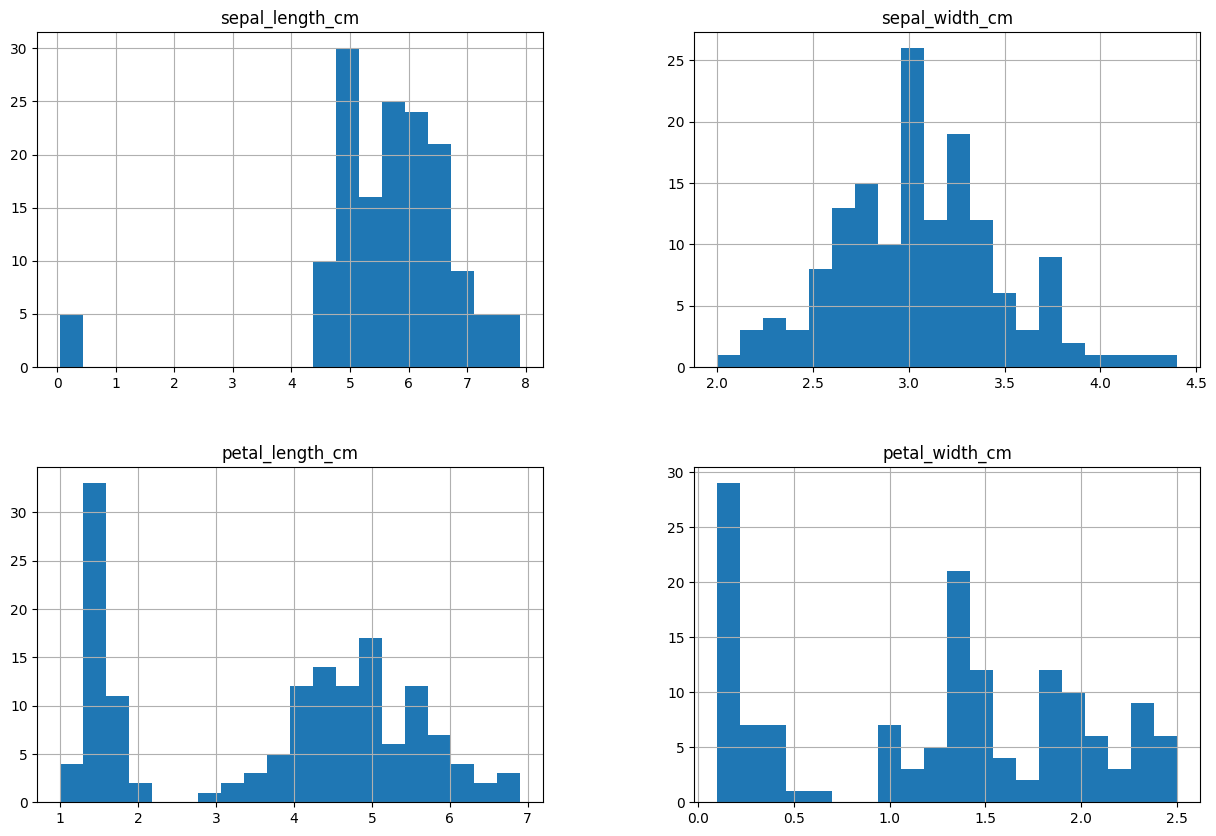

In [372]:
# Instalar las librerías necesarias
!pip install numpy pandas scikit-learn matplotlib seaborn

import matplotlib.pyplot as plt

# Crear histogramas para cada columna numérica
iris.hist(bins=20, figsize=(15, 10))
plt.show()


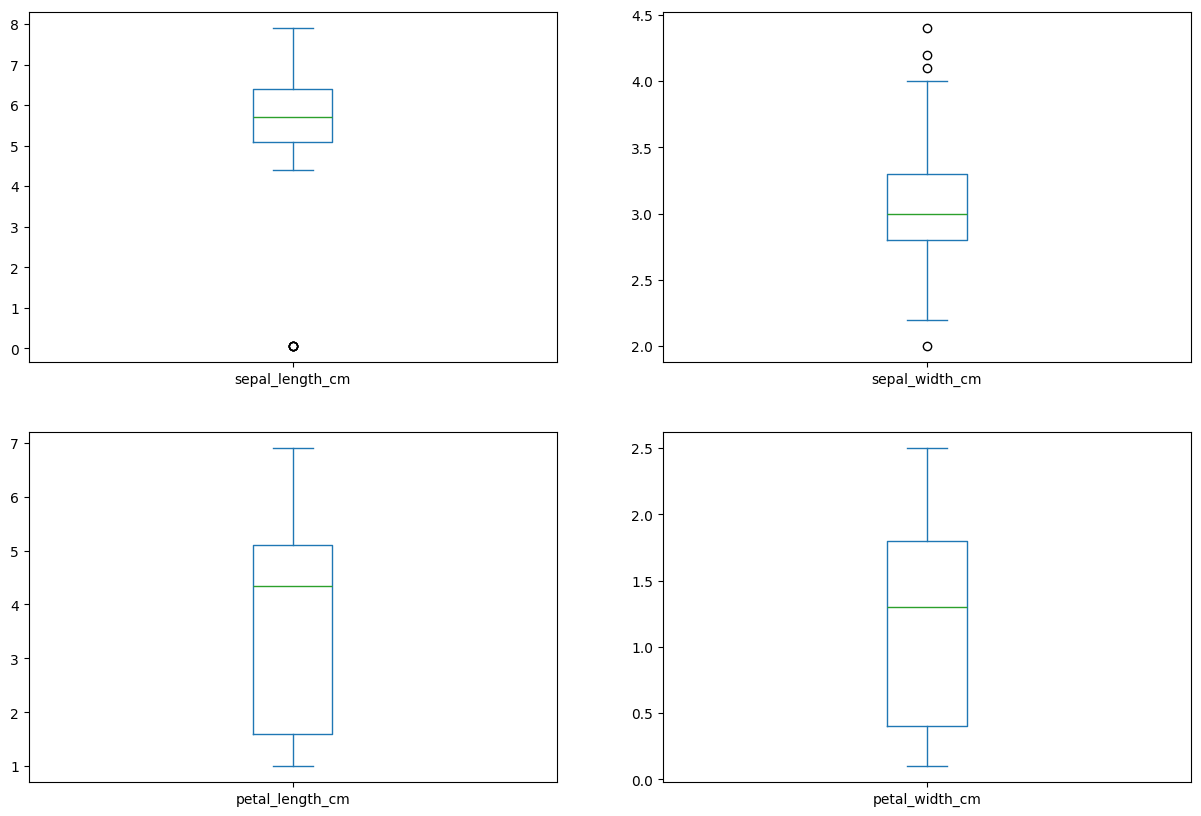

In [373]:
# Crear un gráfico de caja para cada columna numérica
iris.plot(kind='box', subplots=True, layout=(2, 2), figsize=(15, 10))
plt.show()


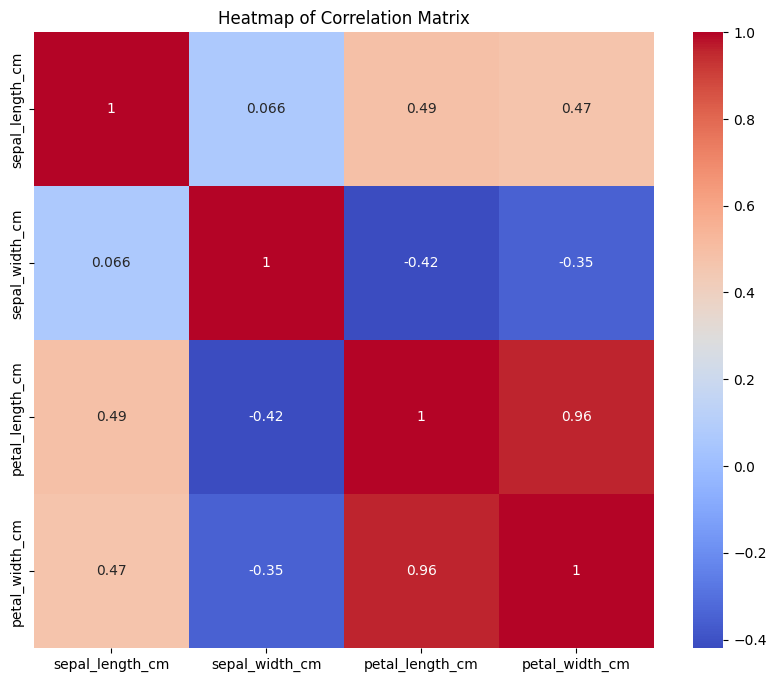

In [374]:
import seaborn as sns

# Calcular la matriz de correlación
corr_matrix = numericas.corr()

# Crear un mapa de calor de la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Heatmap of Correlation Matrix')
plt.show()


## Acomodamos los valores extraños 
### Teniendo en cuenta que tenemos valores con errores en la 

### Columna petal_width_cm vemos que son valores 0.2 

In [375]:
# Reemplazar valores menores a 1 por su valor multiplicado por 10
iris['petal_width_cm'] = iris['petal_width_cm'].apply(lambda x: x * 10 if x < 1 else x)

# Verificar el resultado
iris[['petal_width_cm']]



,petal_width_cm
0,2.0
1,2.0
2,2.0
3,2.0
4,2.0
...,...
145,2.3
146,2.3
147,2.0
148,2.3


### Reemplazar valores menores a 1 por su valor multiplicado por 100

In [376]:
# Reemplazar valores menores a 1 por su valor multiplicado por 100
iris["sepal_length_cm"] = iris["sepal_length_cm"].apply(lambda x: x * 100 if x < 1 else x)

# Verificar el resultado
print(iris[['petal_width_cm']])



     petal_width_cm
0               2.0
1               2.0
2               2.0
3               2.0
4               2.0
..              ...
145             2.3
146             2.3
147             2.0
148             2.3
149             1.8

[150 rows x 1 columns]


In [377]:
# Definir rangos específicos para los valores de cada columna numérica
rangos_superiores = {'sepal_length_cm': 8, 'sepal_width_cm': 6, 'petal_length_cm': 8, 'petal_width_cm': 7}
rangos_inferiores = {'sepal_length_cm': 1.0, 'sepal_width_cm': 1.0, 'petal_length_cm': 1.0, 'petal_width_cm': 1}

# Filtrar filas con valores fuera de los rangos específicos en cualquier columna numérica
filas_fuera_rango = iris[(iris['sepal_length_cm'] > rangos_superiores['sepal_length_cm']) | (iris['sepal_length_cm'] < rangos_inferiores['sepal_length_cm']) |
                         (iris['sepal_width_cm'] > rangos_superiores['sepal_width_cm']) | (iris['sepal_width_cm'] < rangos_inferiores['sepal_width_cm']) |
                         (iris['petal_length_cm'] > rangos_superiores['petal_length_cm']) | (iris['petal_length_cm'] < rangos_inferiores['petal_length_cm']) |
                         (iris['petal_width_cm'] > rangos_superiores['petal_width_cm']) | (iris['petal_width_cm'] < rangos_inferiores['petal_width_cm'])]
print(filas_fuera_rango)


Empty DataFrame
Columns: [sepal_length_cm, sepal_width_cm, petal_length_cm, petal_width_cm, class]
Index: []


## Identificar columnas con valore nulos 

In [378]:
# Filtrar filas con valores nulos en cualquier columna numérica
filas_nulas = iris[iris[['sepal_length_cm', 'sepal_width_cm', 'petal_length_cm', 'petal_width_cm']].isnull().any(axis=1)]
filas_nulas


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,class
7,5.0,3.4,1.5,NaN,Iris-setosa
8,4.4,2.9,1.4,NaN,Iris-setosa
9,4.9,3.1,1.5,NaN,Iris-setosa
10,5.4,3.7,1.5,NaN,Iris-setosa
11,4.8,3.4,1.6,NaN,Iris-setosa


In [379]:
# Contar el número de filas en el DataFrame 'iris'
total_rows = iris.shape[0]
print("Número total de filas en 'iris':", total_rows)

# Contar el número de filas en el DataFrame 'missing_values'
missing_rows = missing_values.shape[0]
print("Número de filas con valores faltantes en 'missing_values':", missing_rows)

Número total de filas en 'iris': 150
Número de filas con valores faltantes en 'missing_values': 5


In [380]:
# Contar el número total de filas en el DataFrame 'austin'
total_rows = iris.shape[0]

# Contar el número de filas con valores faltantes en el DataFrame 'missing_values'
missing_rows = missing_values.shape[0]

# Calcular la proporción de filas faltantes respecto al total de filas
missing_ratio = missing_rows / total_rows
print("Proporción de filas faltantes:", missing_ratio)

Proporción de filas faltantes: 0.03333333333333333


## Dropeamos valores nulos
### tenemos encuenta que representan el 3% del data set 
#### decidimos sustituir el valor nulo por la media asi no afectar el data set 

In [381]:
# Calcular la media de la columna 'petal_width_cm'
media_petal_width = iris['petal_width_cm'].mean()

# Rellenar los valores nulos con la media sin usar inplace=True
iris['petal_width_cm'] = iris['petal_width_cm'].fillna(media_petal_width)

# Verificar el resultado
iris[['petal_width_cm']]


,petal_width_cm
0,2.0
1,2.0
2,2.0
3,2.0
4,2.0
...,...
145,2.3
146,2.3
147,2.0
148,2.3


In [382]:
#  Verificamos si tenemos valores nulos
filas_nulas2 = iris[iris[['sepal_length_cm', 'sepal_width_cm', 'petal_length_cm', 'petal_width_cm']].isnull().any(axis=1)]
filas_nulas2


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,class


In [383]:
iris


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,class
0,5.1,3.5,1.4,2.0,Iris-setosa
1,4.9,3.0,1.4,2.0,Iris-setosa
2,4.7,3.2,1.3,2.0,Iris-setosa
3,4.6,3.1,1.5,2.0,Iris-setosa
4,5.0,3.6,1.4,2.0,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,2.3,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


## Tenemos encuenta que dos categorias son las mismas con diferente manera de escrirbir

In [394]:
# Reemplazar los valores incorrectos en la columna 'class'
iris['class'] = iris['class'].replace({'Iris-setossa': 'Iris-setosa', 'versicolor': 'Iris-versicolor'})

# Verificar el resultado
print(iris['class'].value_counts())


class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


## Convertimos nuestra columna categorica a numeros 
### Creamos la lista de clases 

### Pasamos los datos a sus respectivas columnas 

In [395]:
# Definir la lista de clases correctamente
class_list = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

# Crear nuevas columnas basadas en la lista de clases y rellenar valores nulos
for clas in class_list:
    iris[clas] = iris['class'].apply(lambda x: 1 if clas in x else 0)


# Verificar el resultado
iris.head()


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,class,Iris-setosa,Iris-versicolor,Iris-virginica
0,5.1,3.5,1.4,2.0,Iris-setosa,1,0,0
1,4.9,3.0,1.4,2.0,Iris-setosa,1,0,0
2,4.7,3.2,1.3,2.0,Iris-setosa,1,0,0
3,4.6,3.1,1.5,2.0,Iris-setosa,1,0,0
4,5.0,3.6,1.4,2.0,Iris-setosa,1,0,0


In [396]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sepal_length_cm  150 non-null    float64
 1   sepal_width_cm   150 non-null    float64
 2   petal_length_cm  150 non-null    float64
 3   petal_width_cm   150 non-null    float64
 4   class            150 non-null    object 
 5   Iris-setosa      150 non-null    int64  
 6   Iris-versicolor  150 non-null    int64  
 7   Iris-virginica   150 non-null    int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 9.5+ KB


In [397]:
iris

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,class,Iris-setosa,Iris-versicolor,Iris-virginica
0,5.1,3.5,1.4,2.0,Iris-setosa,1,0,0
1,4.9,3.0,1.4,2.0,Iris-setosa,1,0,0
2,4.7,3.2,1.3,2.0,Iris-setosa,1,0,0
3,4.6,3.1,1.5,2.0,Iris-setosa,1,0,0
4,5.0,3.6,1.4,2.0,Iris-setosa,1,0,0
...,...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica,0,0,1
146,6.3,2.5,5.0,2.3,Iris-virginica,0,0,1
147,6.5,3.0,5.2,2.0,Iris-virginica,0,0,1
148,6.2,3.4,5.4,2.3,Iris-virginica,0,0,1


In [398]:
# Identificar las filas que contienen valores nulos
filas_nulas = iris[iris.isnull().any(axis=1)]

# Mostrar las filas nulas
filas_nulas


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,class,Iris-setosa,Iris-versicolor,Iris-virginica


## Eliminamos la columna class

In [399]:
# Eliminar la columna 'class'
iris = iris.drop(columns=['class'])

# Verificar el resultado
iris.head()


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,Iris-setosa,Iris-versicolor,Iris-virginica
0,5.1,3.5,1.4,2.0,1,0,0
1,4.9,3.0,1.4,2.0,1,0,0
2,4.7,3.2,1.3,2.0,1,0,0
3,4.6,3.1,1.5,2.0,1,0,0
4,5.0,3.6,1.4,2.0,1,0,0


In [400]:
# Verificar si hay valores nulos en el DataFrame
valores_nulos = iris.isnull().sum()

# Mostrar el resultado
print(valores_nulos)


sepal_length_cm    0
sepal_width_cm     0
petal_length_cm    0
petal_width_cm     0
Iris-setosa        0
Iris-versicolor    0
Iris-virginica     0
dtype: int64


## dividimos nuestro data set limpio en x , y 
### y duvidimos el data set en conjuntos de entrenamiento y prueba

In [404]:
# Asignar la columna  a y
y = iris["sepal_length_cm"]

# Asignar las columnas restantes a X
X = iris[["sepal_width_cm","petal_length_cm","petal_width_cm","Iris-setosa","Iris-versicolor","Iris-virginica"]]

# Verificar las primeras filas de X y y
X.head(),y.head()

(   sepal_width_cm  petal_length_cm  petal_width_cm  Iris-setosa  \
 0             3.5              1.4             2.0            1   
 1             3.0              1.4             2.0            1   
 2             3.2              1.3             2.0            1   
 3             3.1              1.5             2.0            1   
 4             3.6              1.4             2.0            1   
 
    Iris-versicolor  Iris-virginica  
 0                0               0  
 1                0               0  
 2                0               0  
 3                0               0  
 4                0               0  ,
 0    5.1
 1    4.9
 2    4.7
 3    4.6
 4    5.0
 Name: sepal_length_cm, dtype: float64)

In [405]:
from sklearn.model_selection import train_test_split

In [406]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verificar las dimensiones de los conjuntos de datos
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((120, 6), (30, 6), (120,), (30,))

In [407]:
iris

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,Iris-setosa,Iris-versicolor,Iris-virginica
0,5.1,3.5,1.4,2.0,1,0,0
1,4.9,3.0,1.4,2.0,1,0,0
2,4.7,3.2,1.3,2.0,1,0,0
3,4.6,3.1,1.5,2.0,1,0,0
4,5.0,3.6,1.4,2.0,1,0,0
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,0,0,1
146,6.3,2.5,5.0,2.3,0,0,1
147,6.5,3.0,5.2,2.0,0,0,1
148,6.2,3.4,5.4,2.3,0,0,1
